<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/LateFusionCNN_cleaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Class balance:
  class 0: 477 samples (47.7 %)
  class 1: 523 samples (52.3 %)

Split sizes -> train: 720, val: 180, test: 100
Test set indices from 1K data: [477 837 302 405 333 332 886 730 775 741 601 732 195 112 796 486 827 977
 181 890 800 150 403 972 597 463  38 661 806 535 206 537 298 933 891 746
 742  56 419 936 636  25   6 327 522 215 276 196  50 624  18 367 131 764
 924 629 586 638 783 471 600 685 118 482 965 409 319 673 184 849 331 285
  47 978 465 454 528 826 502 224 666 993 557 544 408 999 348 123 113 714
 404 261 375 381 177 277 724 704 887 504]
Epoch 1/60: train loss=0.7488, train acc=0.4639, val loss=0.7084, val acc=0.4556
Epoch 2/60: train loss=0.7270, train acc=0.4833, val loss=0.6949, val acc=0.5278
Epoch 3/60: train loss=0.6958, train acc=0.5167, val loss=0.6739, val acc=0.5722
Epoch 4/60: train loss=0.6778, train acc=0.5667, val loss=0.6564, val acc=0.6333
Epoch 5/60: train loss=0.6708, train acc=0.5722, val loss=0.6436, val acc=0.6556
Epoch 6/60: train loss=0.6596,

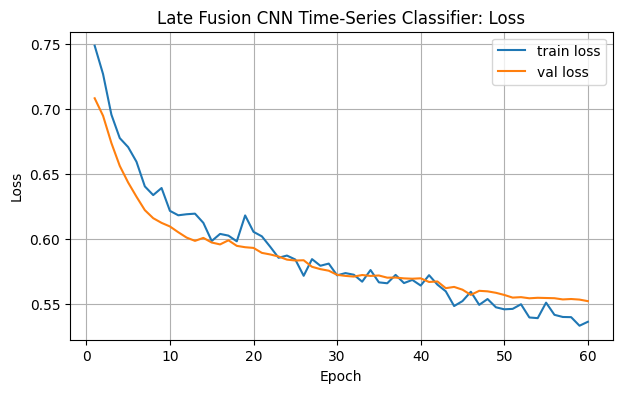

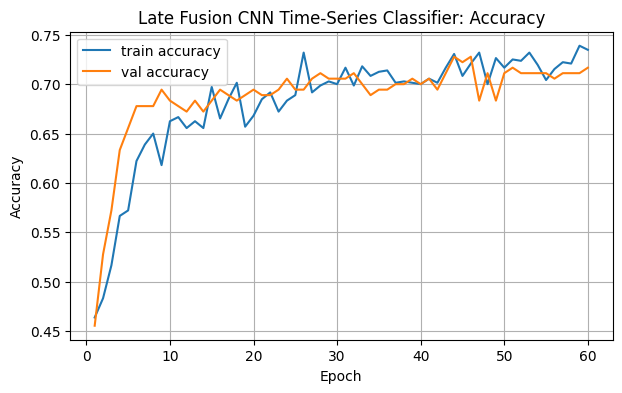


 Idx  True  Pred  Confidence  Uncertainty
   0     1     1      0.5651       0.6846
   1     1     1      0.9963       0.0246
   2     1     1      0.5461       0.6889
   3     0     0      0.7909       0.5128
   4     1     1      0.6678       0.6357
   5     1     1      0.7553       0.5565
   6     0     0      0.7439       0.5690
   7     0     0      0.5147       0.6927
   8     0     1      0.5099       0.6930
   9     0     0      0.8137       0.4808
  10     0     1      0.8016       0.4982
  11     0     1      0.6993       0.6114
  12     1     0      0.7399       0.5732
  13     1     1      0.7099       0.6023
  14     1     1      0.5285       0.6915
  15     1     0      0.7688       0.5407
  16     0     0      0.8046       0.4939
  17     1     1      0.7669       0.5430
  18     1     1      0.6716       0.6331
  19     1     1      0.8340       0.4494
  20     0     0      0.6735       0.6317
  21     0     1      0.5025       0.6931
  22     0     0      0.6316     

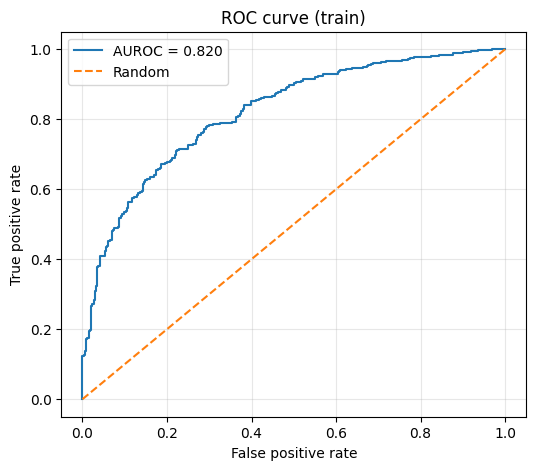

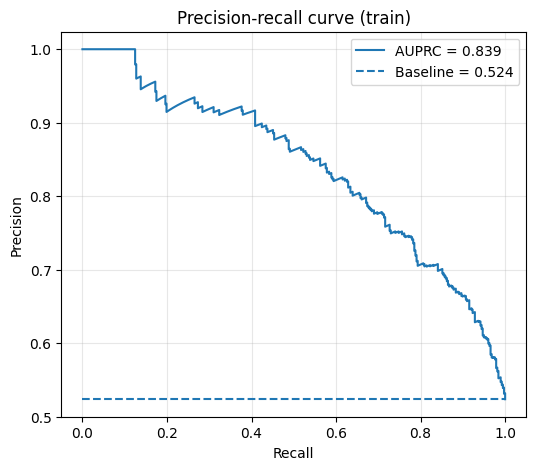

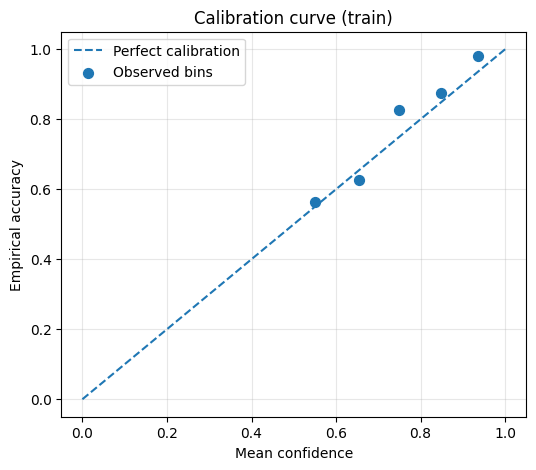

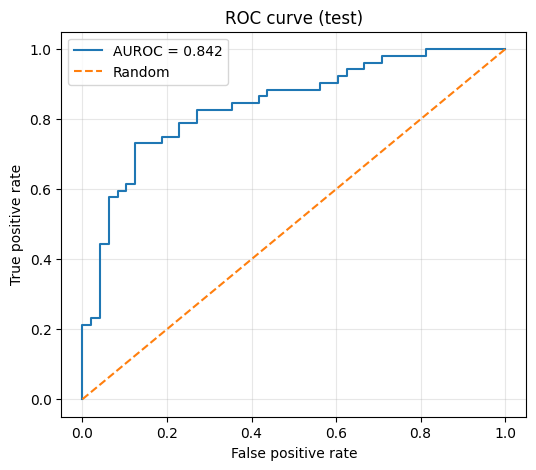

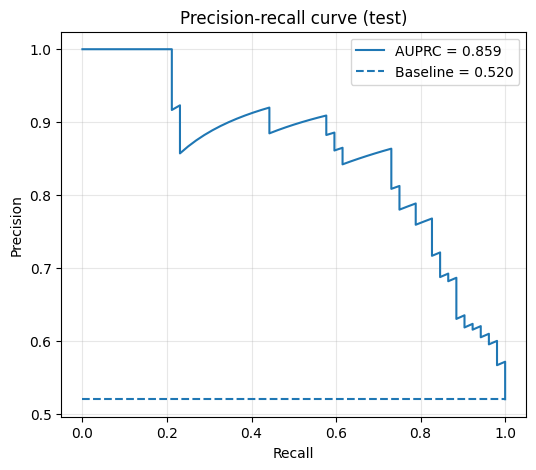

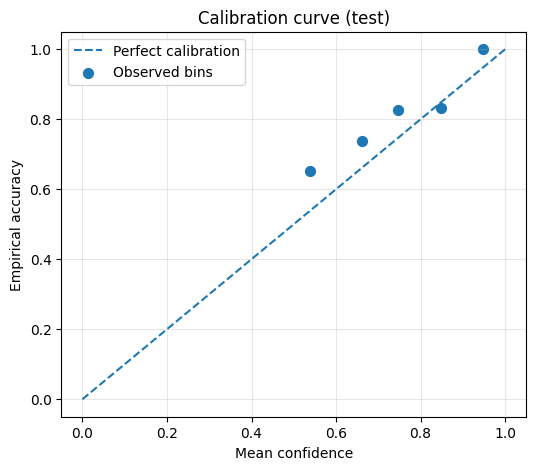

In [9]:
"""
HeartDiseaseNet: 12-lead ECG + demographic multi-modal classifier for
structural heart disease (shd_moderate_or_greater_flag).

Pipeline (in order):
  1. Load raw ECG waveforms, ECG summary metrics, and demographic/outcome data.
  2. Bandpass-filter every 12-lead waveform.
  3. One-hot encode categorical demographic fields (done BEFORE splitting).
  4. Split into train / val / test = 72% / 18% / 10% (test is 10% of everything;
     the remaining 90% is split 80/20 into train/val).
  5. Fit the scaler + KNN imputer on train+val ONLY, then transform test with
     those already-fitted objects (no test-set leakage).
  6. Build PyTorch DataLoaders and train the late-fusion CNN (architecture and
     hyperparameters are unchanged from the original notebook).
  7. Evaluate on train and on the held-out test set: per-sample predictions,
     confidence, and an uncertainty proxy; AUROC, AUPRC, Brier score,
     expected calibration error (ECE), and confusion matrices for both.

NOTE ON THE WAVEFORM FILTER: the original notebook imported
`scipy.signal.butter/filtfilt/find_peaks` twice but never defined a filtering
function with them. `bandpass_filter_ecg` below fills that gap with standard
12-lead ECG bandpass defaults (0.5-40 Hz, 4th-order Butterworth, zero-phase).
Replace FILTER_LOW_HZ / FILTER_HIGH_HZ / ECG_SAMPLING_RATE_HZ if your actual
filter design differs.
"""


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    roc_curve,
    precision_recall_curve,
)

# ===========================================================================
# 0. Reproducibility and device
# ===========================================================================
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_SAMPLES = 1000  # number of aligned ECG / demographic / label rows to use


# ===========================================================================
# 1. Load raw data
# ===========================================================================
ECG_data_1K = np.load("ECG_waveforms_1K.npy")       # raw 12-lead waveforms
Echo_5K = pd.read_csv("EchoNext_EchoData_5K.csv")   # demographics + outcome label

y_all = np.array(Echo_5K["shd_moderate_or_greater_flag"][:N_SAMPLES])

X_raw = ECG_data_1K[:N_SAMPLES]            # shape [N, L, 12]
X_ts_raw = np.swapaxes(X_raw, 1, 2)        # -> [N, 12, L]; Conv1d expects [N, C, L]

unique, counts = np.unique(y_all, return_counts=True)
print("Class balance:")
for cls, cnt in zip(unique.tolist(), counts.tolist()):
    print(f"  class {cls}: {cnt} samples ({cnt / len(y_all) * 100:.1f} %)")


# ===========================================================================
# 2. Bandpass-filter the ECG waveforms
# ===========================================================================
ECG_SAMPLING_RATE_HZ = 500   # adjust to your true acquisition rate
FILTER_LOW_HZ = 0.5          # removes baseline wander
FILTER_HIGH_HZ = 40.0        # removes high-frequency EMG / powerline noise
FILTER_ORDER = 4


def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    """Zero-phase Butterworth bandpass filter applied along the time axis.

    Args:
        signal_array: array of shape [N, C, L].
    Returns:
        Filtered array, same shape, dtype float32.
    """
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=-1)
    return filtered.astype(np.float32)


X_ts_filtered = bandpass_filter_ecg(X_ts_raw)


# ===========================================================================
# 3. Demographic preprocessing: one-hot encode BEFORE splitting
# ===========================================================================
# One-hot encoding only depends on which category a row belongs to, not on any
# statistic estimated from the data (unlike scaling or imputation), so doing it
# before the split cannot leak train/test information.
DEMOG_COLUMNS = [
    "age_at_ecg", "sex", "race_ethnicity", "ventricular_rate",
    "atrial_rate", "pr_interval", "qrs_duration", "qt_corrected",
]

df_demog = pd.DataFrame(np.array(Echo_5K[DEMOG_COLUMNS][:N_SAMPLES]), columns=DEMOG_COLUMNS)
df_encoded = pd.get_dummies(
    df_demog, columns=["sex", "race_ethnicity"], dummy_na=True, drop_first=False
)
demog_dim = df_encoded.shape[1]


# ===========================================================================
# 4. Train / validation / test split
#    test = 10% of all data; remaining 90% split 80/20 into train/val
#    (=> 72% train, 18% val, 10% test). Stratified on the label so class
#    balance is preserved across all three splits.
# ===========================================================================
all_idx = np.arange(N_SAMPLES)

trainval_idx, test_idx = train_test_split(
    all_idx, test_size=0.10, random_state=42, stratify=y_all
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.20, random_state=42, stratify=y_all[trainval_idx]
)
trainval_idx_sorted = np.concatenate([train_idx, val_idx])

print(f"\nSplit sizes -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")
print(f"Test set indices from 1K data: {test_idx}")

# ===========================================================================
# 5. Scale, then KNN-impute demographic features
#
#    DECISION: both the scaler and the imputer are fit on train+val ONLY,
#    then just *applied* (transform) to test. This mirrors real deployment,
#    where test-set statistics (its mean/variance for scaling, or which rows
#    can serve as imputation neighbors) must never inform preprocessing --
#    otherwise test metrics become optimistically biased (leakage). We fit
#    on train+val jointly (rather than train alone) because the task calls
#    for imputation to run "only on training/validation data"; it's
#    consistent to fit the scaler over that same partition. Scaling is done
#    before imputation (matching the original notebook's order) since KNN
#    imputation is distance-based and needs features on comparable scales.
# ===========================================================================
scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=3)

scaler.fit(df_encoded.iloc[trainval_idx_sorted])
demog_scaled_full = pd.DataFrame(scaler.transform(df_encoded), columns=df_encoded.columns)

imputer.fit(demog_scaled_full.iloc[trainval_idx_sorted])
# KNNImputer.transform looks up nearest neighbors from whatever it was fit on
# (train+val), so calling transform on the full array still never lets test
# rows act as neighbors for each other or for train/val.
demog_clean_full = imputer.transform(demog_scaled_full)


# ===========================================================================
# 6. Build per-split tensors and DataLoaders
# ===========================================================================
def make_loader(idx, batch_size, shuffle):
    X_ts_t = torch.tensor(X_ts_filtered[idx], dtype=torch.float32, device=device)
    X_demog_t = torch.tensor(demog_clean_full[idx], dtype=torch.float32, device=device)
    y_t = torch.tensor(y_all[idx], dtype=torch.long, device=device)
    dataset = TensorDataset(X_ts_t, X_demog_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


ts_train_loader = make_loader(train_idx, batch_size=32, shuffle=True)
ts_val_loader = make_loader(val_idx, batch_size=128, shuffle=False)
ts_test_loader = make_loader(test_idx, batch_size=128, shuffle=False)


# ===========================================================================
# 7. Model definition (architecture unchanged from the source notebook)
# ===========================================================================
class DemographicMLP(nn.Module):
    """Small MLP that embeds the demographic feature vector."""

    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.mlp(x)


class LateFusionHeartDiseaseModel(nn.Module):
    """1D CNN over the 12-lead ECG, late-fused with a demographic MLP embedding."""

    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):
        super().__init__()

        # ECG waveform feature extractor.
        self.ts_features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool1d(250),  # 2500 -> 250

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.AdaptiveAvgPool1d(25),   # 250 -> 25

            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.AdaptiveAvgPool1d(1),    # 25 -> 1
        )

        # Demographic feature extractor.
        self.demog_features = DemographicMLP(input_dim=demog_dim, output_dim=16)

        # Late-fusion classifier: 32 (ECG) + 16 (demographic) = 48 features.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 + 16, num_classes),
        )

    def forward(self, ts_input, demog_input):
        ts_emb = torch.flatten(self.ts_features(ts_input), start_dim=1)
        demog_emb = self.demog_features(demog_input)
        fused = torch.cat((ts_emb, demog_emb), dim=1)
        return self.classifier(fused)


# ===========================================================================
# 8. Training loop (unchanged hyperparameters: Adam, weight_decay=5e-2,
#    CosineAnnealingWarmRestarts(T_0=20), epochs=60, lr=1e-4)
# ===========================================================================
def train_classifier(model, train_loader, val_loader=None, epochs=5, learning_rate=1e-3):
    """Train `model` and return per-epoch loss/accuracy history.

    `val_loader`, if given, is evaluated each epoch purely for monitoring --
    it is never used to fit any preprocessing step or to pick weights, so the
    held-out test set stays completely untouched until final evaluation.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=5e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=1e-5
    )
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for X_batch, demog_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            demog_batch = demog_batch.to(device)
            y_batch = y_batch.to(device)

            # Light augmentation on the waveform only (never on demographics).
            X_batch = X_batch + 0.05 * torch.randn_like(X_batch)
            X_batch = X_batch * (0.8 + 0.4 * torch.rand(1, device=device))

            optimizer.zero_grad()
            logits = model(X_batch, demog_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            b = X_batch.shape[0]
            total_loss += loss.item() * b
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total += b

        scheduler.step()

        history["train_loss"].append(total_loss / total)
        history["train_acc"].append(correct / total)

        if val_loader is not None:
            val_loss, val_acc = evaluate_classifier(model, val_loader, criterion)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs}: train loss={history['train_loss'][-1]:.4f}, "
            f"train acc={history['train_acc'][-1]:.4f}"
            + (f", val loss={history['val_loss'][-1]:.4f}, val acc={history['val_acc'][-1]:.4f}"
               if val_loader is not None else "")
        )

    return history


def evaluate_classifier(model, data_loader, criterion=None):
    """Compute mean loss and accuracy of `model` over `data_loader`."""
    model.eval()
    criterion = criterion or nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, demog_batch, y_batch in data_loader:
            X_batch, demog_batch, y_batch = X_batch.to(device), demog_batch.to(device), y_batch.to(device)
            logits = model(X_batch, demog_batch)
            loss = criterion(logits, y_batch)
            b = X_batch.shape[0]
            total_loss += loss.item() * b
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total += b

    return total_loss / total, correct / total


def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if history["val_loss"]:
        plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{title}: Loss")
    plt.grid(True); plt.legend(); plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if history["val_acc"]:
        plt.plot(epochs, history["val_acc"], label="val accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(f"{title}: Accuracy")
    plt.grid(True); plt.legend(); plt.show()


# ===========================================================================
# 9. Instantiate and train (hyperparameters unchanged: epochs=60, lr=1e-4)
# ===========================================================================
fusion_model = LateFusionHeartDiseaseModel(
    sequence_length=2500, num_classes=2, in_channels=12, demog_dim=demog_dim
)

ts_history = train_classifier(
    model=fusion_model,
    train_loader=ts_train_loader,
    val_loader=ts_val_loader,     # monitoring only; test set stays untouched
    epochs=60,
    learning_rate=1e-4,
)

plot_history(ts_history, title="Late Fusion CNN Time-Series Classifier")


# ===========================================================================
# 10. Metric helpers
# ===========================================================================
def as_numpy(x):
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)


@torch.no_grad()
def collect_predictions(model, data_loader):
    """Run `model` over `data_loader` and collect labels + softmax probabilities."""
    model.eval()
    all_y, all_probs = [], []

    for X_ts_b, X_demo_b, y_b in data_loader:
        X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
        probs = F.softmax(model(X_ts_b, X_demo_b), dim=-1)
        all_y.append(y_b.cpu())
        all_probs.append(probs.cpu())

    y_true = torch.cat(all_y).numpy()
    probs = torch.cat(all_probs).numpy()
    return y_true, probs, probs.argmax(axis=1)


def predictive_entropy(probs):
    """Shannon entropy of the predicted class distribution.

    Used here as an uncertainty proxy. IMPORTANT: this model is a
    deterministic (non-Bayesian) network, so this only reflects how spread
    out a single forward pass's softmax output is -- it is NOT epistemic
    (model) uncertainty, which would require a Bayesian NN or a deep ensemble.
    """
    eps = 1e-12
    p = np.clip(probs, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)


def calculate_binary_classification_metrics(y_true, probs, n_bins=10):
    """AUROC, AUPRC, Brier score, NLL, ECE, and confusion counts."""
    y_pred = probs.argmax(axis=1)
    p1 = probs[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for m in range(n_bins):
        lo, hi = bin_edges[m], bin_edges[m + 1]
        in_bin = (confidence >= lo) & (confidence <= hi) if m == 0 else (confidence > lo) & (confidence <= hi)
        if np.any(in_bin):
            ece += np.mean(in_bin) * abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))

    return {
        "accuracy": np.mean(y_true == y_pred),
        "auroc": roc_auc_score(y_true, p1) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, p1) if len(np.unique(y_true)) > 1 else np.nan,
        "brier_score": np.mean((p1 - y_true) ** 2),
        "negative_log_likelihood": log_loss(y_true, probs, labels=[0, 1]),
        "expected_calibration_error": ece,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


def plot_roc_curve(y_true, probs, title_suffix=""):
    p1 = probs[:, 1]
    fpr, tpr, _ = roc_curve(y_true, p1)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {roc_auc_score(y_true, p1):.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.title(f"ROC curve {title_suffix}"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()


def plot_precision_recall_curve(y_true, probs, title_suffix=""):
    p1 = probs[:, 1]
    precision, recall, _ = precision_recall_curve(y_true, p1)
    prevalence = np.mean(y_true == 1)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {average_precision_score(y_true, p1):.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"Precision-recall curve {title_suffix}"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()


def plot_calibration_curve(y_true, probs, n_bins=10, title_suffix=""):
    confidence = probs.max(axis=1)
    correct = (probs.argmax(axis=1) == y_true).astype(float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    mean_conf, emp_acc = [], []
    for m in range(n_bins):
        lo, hi = bin_edges[m], bin_edges[m + 1]
        in_bin = (confidence >= lo) & (confidence <= hi) if m == 0 else (confidence > lo) & (confidence <= hi)
        if np.any(in_bin):
            mean_conf.append(np.mean(confidence[in_bin]))
            emp_acc.append(np.mean(correct[in_bin]))

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(mean_conf, emp_acc, s=50, label="Observed bins")
    plt.xlabel("Mean confidence"); plt.ylabel("Empirical accuracy")
    plt.title(f"Calibration curve {title_suffix}"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()


# ===========================================================================
# 11. Evaluate on the held-out test set: per-sample predictions
# ===========================================================================
y_true_test, probs_test, y_pred_test = collect_predictions(fusion_model, ts_test_loader)
confidence_test = probs_test.max(axis=1)
uncertainty_test = predictive_entropy(probs_test)

print(f"\n{'Idx':>4} {'True':>5} {'Pred':>5} {'Confidence':>11} {'Uncertainty':>12}")
for i in range(len(y_true_test)):
    print(f"{i:>4} {y_true_test[i]:>5} {y_pred_test[i]:>5} "
          f"{confidence_test[i]:>11.4f} {uncertainty_test[i]:>12.4f}")


# ===========================================================================
# 12. Metrics for both the training set and the held-out test set
# ===========================================================================
y_true_train, probs_train, y_pred_train = collect_predictions(fusion_model, ts_train_loader)

train_metrics = calculate_binary_classification_metrics(y_true_train, probs_train)
test_metrics = calculate_binary_classification_metrics(y_true_test, probs_test)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["train", "test"]).T
print("\nClassification metrics (train vs. test):")
print(metrics_df)

print("\nConfusion matrix (train) [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_train, y_pred_train, labels=[0, 1]))
print("Confusion matrix (test) [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred_test, labels=[0, 1]))

plot_roc_curve(y_true_train, probs_train, title_suffix="(train)")
plot_precision_recall_curve(y_true_train, probs_train, title_suffix="(train)")
plot_calibration_curve(y_true_train, probs_train, title_suffix="(train)")

plot_roc_curve(y_true_test, probs_test, title_suffix="(test)")
plot_precision_recall_curve(y_true_test, probs_test, title_suffix="(test)")
plot_calibration_curve(y_true_test, probs_test, title_suffix="(test)")